In [1]:
# Cell 1: Import Libraries
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
import tensorflow as tf

## Data Preprocessing

In [2]:
# Cell 2: Check dataset structure
print("Dataset folders:", os.listdir("Dataset"))
print("Training subfolders:", os.listdir("Dataset/Training"))
print("Testing subfolders:", os.listdir("Dataset/Testing"))

Dataset folders: ['README.txt', 'Testing', 'Training']
Training subfolders: ['no tumor', 'tumor']
Testing subfolders: ['no tumor', 'tumor']


In [3]:
datagen = ImageDataGenerator(rescale=1./255) 

In [4]:
train_generator = datagen.flow_from_directory('Dataset/Training',target_size=(64,64),batch_size=32, class_mode="binary",shuffle=False)

Found 8277 images belonging to 2 classes.


In [5]:
test_generator = datagen.flow_from_directory('Dataset/Testing',target_size=(64,64),batch_size=32, class_mode="binary",shuffle=False)

Found 1816 images belonging to 2 classes.


In [6]:
train_generator

In [7]:
data,lable = next(train_generator)  #generates 32 images& their labels from out training data
data.shape

(32, 64, 64, 3)

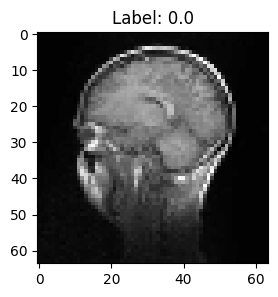

In [8]:
# # Cell 4: Visualize some training images
# data, labels = next(train_generator)

# plt.figure(figsize=(12,6))
# for i in range(8):
#     plt.subplot(2,4,i+1)
#     plt.imshow(data[i])
#     plt.title("Tumor" if labels[i]==1 else "No Tumor")
#     plt.axis("off")
# plt.show()

plt.figure(figsize=(3,3))
plt.imshow(data[18])   # from 32 images take first image
plt.title(f"Label: {lable[20]}") #take label of first image & show it as title of image
plt.show()

In [9]:
train_generator.class_indices

{'no tumor': 0, 'tumor': 1}

## Build the Model

In [10]:
cnn = tf.keras.models.Sequential()
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation="relu", input_shape=[64,64,3]))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))
cnn.add(tf.keras.layers.Flatten())
cnn.add(tf.keras.layers.Dense(units=128, activation='relu'))
cnn.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))  #output layer

C:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compile Model

In [11]:
cnn.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [12]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         802,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 813,217 (3.10 MB)

 Trainable params: 813,217 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

## Train Model

In [13]:
result = cnn.fit(x = train_generator ,epochs = 5)

Epoch 1/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 22s 78ms/step - accuracy: 0.6280 - loss: 0.6584
Epoch 2/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 21s 81ms/step - accuracy: 0.8721 - loss: 0.3475
Epoch 3/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 21s 80ms/step - accuracy: 0.9164 - loss: 0.2432
Epoch 4/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 21s 79ms/step - accuracy: 0.9397 - loss: 0.1866
Epoch 5/5
259/259 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - accuracy: 0.9514 - loss: 0.1542


In [14]:
pred =cnn.predict(test_generator)

57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step


In [26]:
predicted_classes = []
for x in pred:
    if(x >0.5):
        predicted_classes.append(1)
    else:
        predicted_classes.append(0)
print(predicted_classes)

[0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [16]:
true_classes =test_generator.classes

## Save model

In [18]:
# Cell 8: Save trained model
cnn.save("brain_tumor_cnn_model.h5")

## Predict on a Single Image

In [28]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.models import load_model

# Load the trained model
model = load_model("brain_tumor_cnn_model.h5")  # use your trained model file

# Load and preprocess the image
img_path = "Dataset/Training/no tumor/MR0002 (3).jpg"
new_image = load_img(img_path, target_size=(64,64))  # same as training
new_image = img_to_array(new_image)/255.0                 # normalize
new_image = np.expand_dims(new_image, axis=0)            # add batch dimension

# Predict
result = cnn.predict(new_image)
if result[0][0] >= 0.5:
    prediction = 'Tumor Detected'
else:
    prediction = 'No Tumor Detected'

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
No Tumor Detected


## Evaluate on Validation Data

In [29]:
# Evaluate on test dataset
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.9207 - loss: 0.2066
Test Accuracy: 92.07%
Test Loss: 0.2066


In [30]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Reset generator
test_generator.reset()

# Predict on test data
preds = model.predict(test_generator)
pred_labels = (preds > 0.5).astype(int).reshape(-1)
true_labels = test_generator.classes

# Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels)
print("Confusion Matrix:\n", cm)

# Classification Report
cr = classification_report(true_labels, pred_labels, target_names=['No Tumor','Tumor'])
print("\nClassification Report:\n", cr)

57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step
Confusion Matrix:
 [[794 116]
 [ 28 878]]

Classification Report:
               precision    recall  f1-score   support

    No Tumor       0.97      0.87      0.92       910
       Tumor       0.88      0.97      0.92       906

    accuracy                           0.92      1816
   macro avg       0.92      0.92      0.92      1816
weighted avg       0.92      0.92      0.92      1816



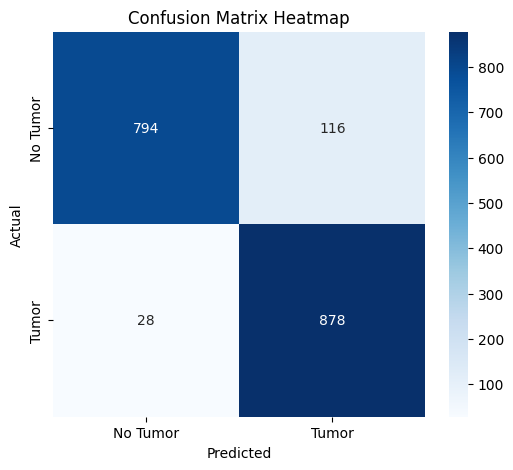

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix (from previous prediction)
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No Tumor','Tumor'],
            yticklabels=['No Tumor','Tumor'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()